In [1]:
from google.colab import drive

drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google'

In [1]:
import sys
import os

sys.path.append(os.path.abspath("..")) 

In [ ]:
import torch

def _patched_solve(B, A):
    return torch.linalg.solve(A, B), None

torch.solve = _patched_solve

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from losses import TimePointOverallLoss
from timepoint import TimePointModel  # your encoder+decoders combined
from synthetic_data.timepoint_dataset import TimePointDataset

In [3]:
def collate_fn(batch):
    return {
        "x": torch.stack([b["x"] for b in batch]),
        "x_w": torch.stack([b["x_w"] for b in batch]),
        "kp": torch.stack([b["kp"] for b in batch]),
        "kp_w": torch.stack([b["kp_w"] for b in batch]),
        "match_mask": torch.stack([b["match_mask"] for b in batch])
    }

In [ ]:
from data_loader import NPZLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

from torch.utils.data import DataLoader

dataset = NPZLoader(
    "../data_cpab",
    use_signal="abp"   # or "cbfv"
)

loader = DataLoader(
    dataset,
    batch_size=2,     
    shuffle=True,
    collate_fn=collate_fn
)

device: cpu


In [5]:
batch = next(iter(loader))

x = batch["x"].unsqueeze(1)       # [B,1,L]
x_w = batch["x_w"].unsqueeze(1)

kp = batch["kp"]                  # [B,L]
kp_w = batch["kp_w"]
match_mask = batch["match_mask"]  # [B,L,L]


In [6]:
model = TimePointModel()
model = model.to(device)

model = TimePointModel().to(device)

criterion = TimePointOverallLoss(
    mp=1.0,
    mn=0.1,
    lambda_desc=1.0
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# forward 
S, D = model(x)
S_w, D_w = model(x_w)

print("S:", S.shape)
print("D:", D.shape)
print("match_mask:", match_mask.shape)

S: torch.Size([2, 1000])
D: torch.Size([2, 1000, 256])
match_mask: torch.Size([2, 1000, 1000])


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in loader:
        x = batch["x"].to(device).unsqueeze(1)     # [B,1,L]
        x_w = batch["x_w"].to(device).unsqueeze(1)

        kp = batch["kp"].to(device)
        kp_w = batch["kp_w"].to(device)

        match_mask = batch["match_mask"].to(device)

        # forward 
        S_logits, D = model(x)
        S_w_logits, D_w = model(x_w)

        # loss
        loss, loss_dict = criterion(
            S_logits, kp,
            S_w_logits, kp_w,
            D, D_w,
            match_mask
        )

        # backward 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch}")
    print(f"Total loss: {total_loss:.4f}")
    print(loss_dict)


Epoch 0
Total loss: 12.2502
{'total': 1.4956896305084229, 'kp_orig': 0.7365821599960327, 'kp_warped': 0.7363728880882263, 'desc': 0.022734634578227997}

Epoch 1
Total loss: 11.8236
{'total': 1.465369701385498, 'kp_orig': 0.7264999747276306, 'kp_warped': 0.7268503904342651, 'desc': 0.012019437737762928}

Epoch 2
Total loss: 11.6124
{'total': 1.4419561624526978, 'kp_orig': 0.7159853577613831, 'kp_warped': 0.7177284955978394, 'desc': 0.008242298848927021}

Epoch 3
Total loss: 11.4134
{'total': 1.416751742362976, 'kp_orig': 0.7045769095420837, 'kp_warped': 0.7073226571083069, 'desc': 0.00485215662047267}

Epoch 4
Total loss: 11.2638
{'total': 1.4020816087722778, 'kp_orig': 0.6981906890869141, 'kp_warped': 0.6992175579071045, 'desc': 0.004673359449952841}

Epoch 5
Total loss: 11.1927
{'total': 1.397328495979309, 'kp_orig': 0.6961080431938171, 'kp_warped': 0.6963258385658264, 'desc': 0.004894667770713568}

Epoch 6
Total loss: 11.1560
{'total': 1.392983317375183, 'kp_orig': 0.694893956184387

In [9]:
def visualize(sample, model):
    model.eval()

    x = sample["x"].unsqueeze(0).unsqueeze(0).to(device)
    x_w = sample["x_w"].unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        S_logits, _ = model(x)
        S_w_logits, _ = model(x_w)

    S = torch.sigmoid(S_logits).cpu().numpy()[0]
    S_w = torch.sigmoid(S_w_logits).cpu().numpy()[0]

    t = np.arange(len(S))

    plt.figure(figsize=(12,5))
    plt.plot(t, sample["x"], label="ABP")
    plt.plot(t, sample["x_w"], label="Warped", alpha=0.7)

    plt.scatter(t[S > 0.5], sample["x"][S > 0.5], color="red", label="KP")
    plt.scatter(t[S_w > 0.5], sample["x_w"][S_w > 0.5], color="blue", label="KP warped")

    plt.legend()
    plt.title("Predicted keypoints")
    plt.show()

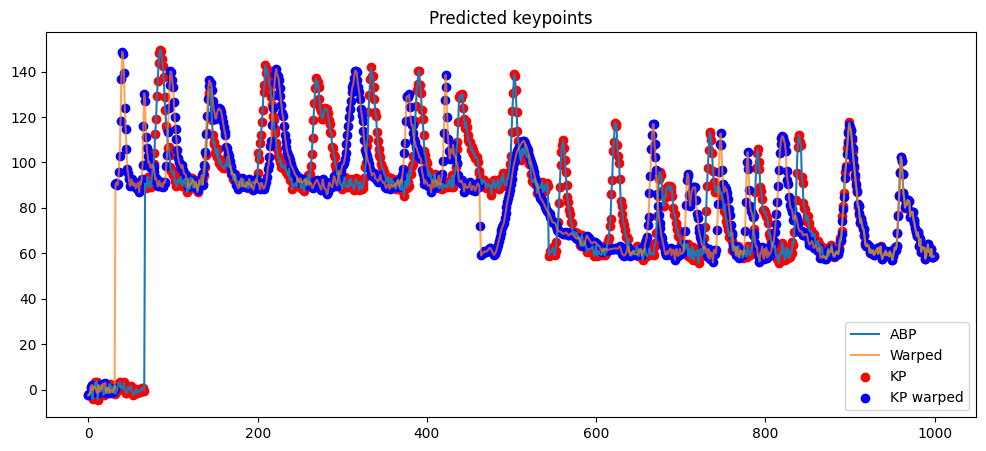

In [11]:
sample = dataset[1]
visualize(sample, model)